In [ ]:
!nvidia-smi

Thu Feb 12 06:43:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/

'Colab Notebooks'
 internn
 satellite-image-classification
'The what you have given the link it is not openin....gsheet'


In [ ]:
labels = {
    '/content/drive/MyDrive/satellite-image-classification/data/cloudy': 'cloudy',
    '/content/drive/MyDrive/satellite-image-classification/data/desert': 'desert',
    '/content/drive/MyDrive/satellite-image-classification/data/green_area': 'green_area',
    '/content/drive/MyDrive/satellite-image-classification/data/water': 'water',
}


In [ ]:
import pandas as pd
import os

data = pd.DataFrame(columns=['image_path', 'label'])

for folder, label in labels.items():
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        data.loc[len(data)] = [image_path, label]

data.to_csv('image_dataset.csv', index=False)
print("CSV created successfully!")


CSV created successfully!


In [ ]:
df = pd.read_csv('image_dataset.csv')
df.head()

,image_path,label
0,/content/drive/MyDrive/satellite-image-classif...,cloudy
1,/content/drive/MyDrive/satellite-image-classif...,cloudy
2,/content/drive/MyDrive/satellite-image-classif...,cloudy
3,/content/drive/MyDrive/satellite-image-classif...,cloudy
4,/content/drive/MyDrive/satellite-image-classif...,cloudy


In [ ]:
!ls /content/drive/MyDrive/satellite-image-classification/data/cloudy

train_10021.jpg  train_17513.jpg  train_26562.jpg  train_36520.jpg
train_10043.jpg  train_17549.jpg  train_26564.jpg  train_36529.jpg
train_10070.jpg  train_17552.jpg  train_26572.jpg  train_36537.jpg
train_10081.jpg  train_17556.jpg  train_26600.jpg  train_36545.jpg
train_10096.jpg  train_17565.jpg  train_26643.jpg  train_36559.jpg
train_10128.jpg  train_17569.jpg  train_2664.jpg   train_36564.jpg
train_10166.jpg  train_1756.jpg   train_26658.jpg  train_3657.jpg
train_10173.jpg  train_17584.jpg  train_26673.jpg  train_36582.jpg
train_10177.jpg  train_17610.jpg  train_26722.jpg  train_36600.jpg
train_101.jpg	 train_17622.jpg  train_26814.jpg  train_36603.jpg
train_10201.jpg  train_17643.jpg  train_26882.jpg  train_36669.jpg
train_10224.jpg  train_17662.jpg  train_26892.jpg  train_36687.jpg
train_10225.jpg  train_17702.jpg  train_26916.jpg  train_36735.jpg
train_10231.jpg  train_17722.jpg  train_26957.jpg  train_36750.jpg
train_10263.jpg  train_17762.jpg  train_2699.jpg   train_36754.jp

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=45,
    vertical_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=(255, 255),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=(255, 255),
    batch_size=32,
    class_mode='categorical'
)


Found 4504 validated image filenames belonging to 4 classes.
Found 1127 validated image filenames belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(255,255,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,492 (56.61 MB)

 Trainable params: 14,839,492 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(255, 255, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # 🔑 FIX
    metrics=['accuracy']
)


In [ ]:
x_batch, y_batch = next(train_generator)
print(x_batch.shape)
print(y_batch.shape)


(32, 255, 255, 3)
(32, 4)


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2097s 15s/step - accuracy: 0.4840 - loss: 1.0314 - val_accuracy: 0.7640 - val_loss: 0.4463
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 94s 668ms/step - accuracy: 0.7894 - loss: 0.4553 - val_accuracy: 0.8314 - val_loss: 0.4033
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 93s 660ms/step - accuracy: 0.8217 - loss: 0.4124 - val_accuracy: 0.8429 - val_loss: 0.3696
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 93s 663ms/step - accuracy: 0.8240 - loss: 0.3910 - val_accuracy: 0.7959 - val_loss: 0.3838
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 93s 657ms/step - accuracy: 0.8281 - loss: 0.3738 - val_accuracy: 0.8305 - val_loss: 0.3949
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 94s 668ms/step - accuracy: 0.8377 - loss: 0.3625 - val_accuracy: 0.8447 - val_loss: 0.3418
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 94s 669ms/step - accuracy: 0.8486 - loss: 0.3510 - val_accuracy: 0.8341 - val_loss: 0.3702
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 94s 663ms/step - accuracy: 0.8401 - loss: 0

In [ ]:
score = model.evaluate(test_generator)
print("Test Accuracy:", score[1])


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.8888 - loss: 0.3086
Test Accuracy: 0.8875110745429993


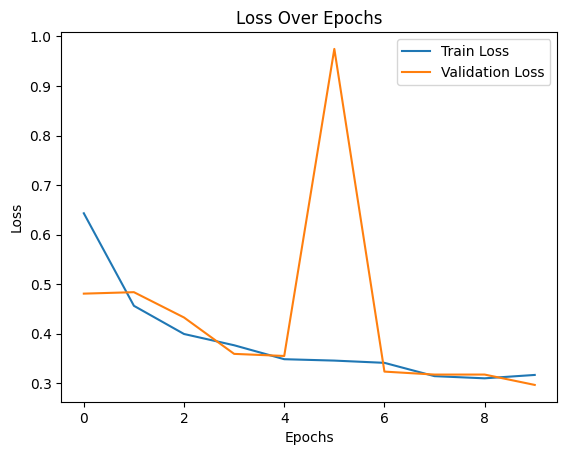

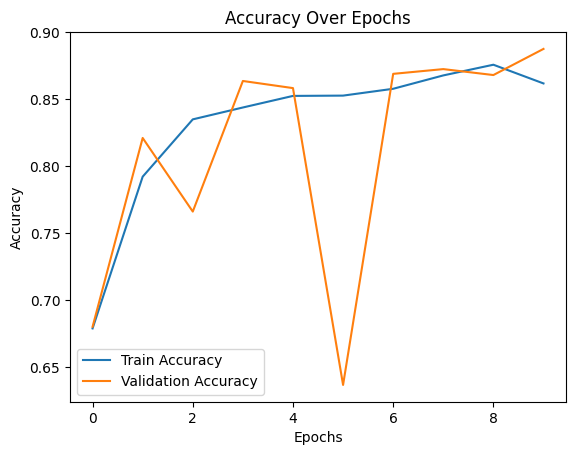

In [ ]:
import matplotlib.pyplot as plt

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
# Save model (recommended format)
model.save('Satellite_Model.keras')

# Load model
from tensorflow.keras.models import load_model
model = load_model('Satellite_Model.keras')

# Recompile (recommended)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir('/content/drive/MyDrive')


['Colab Notebooks',
 'Document 9.pdf',
 'Document 8 (1).pdf',
 'Document 8.pdf',
 'Document 7.pdf',
 'Document 6.pdf',
 'Document 5.pdf',
 'Cyber Security and Privacy.pdf',
 '7509f400-90ec-40be-a27d-ad08f91f1e76.docx',
 'photo.jpg',
 'WhatsApp Image 2025-11-10 at 23.57.53_b7524a0a.jpg',
 'payments.pdf',
 'Resume (1).gdoc',
 'Resume.gdoc',
 'B N Nithya (2).pdf',
 'B N Nithya (1).pdf',
 'B N Nithya.pdf',
 'Public Speaking.pdf',
 'Ethical Hacking.pdf',
 'DOC-20260115-WA0003..pdf',
 'Copy of Public Speaking.pdf',
 'satellite-image-classification',
 'Aicte points.pdf',
 'Video']

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import drive

# Mount drive
drive.mount('/content/drive')

class_names = ['cloudy', 'desert', 'green_area', 'water']

img_path = '/content/drive/MyDrive/satellite-image-classification/data/green_area/Forest_99.jpg'

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_label = class_names[np.argmax(prediction)]

print("Predicted:", predicted_label)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
Predicted: green_area


In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
actual_labels = test_generator.classes

cm = confusion_matrix(actual_labels, predicted_labels)

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step


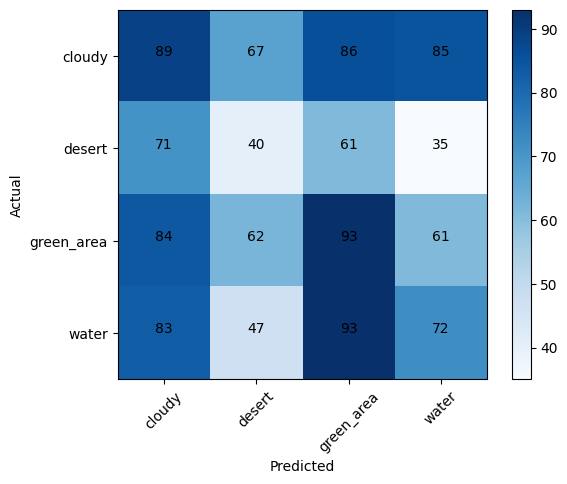

In [ ]:
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(4), class_names, rotation=45)
plt.yticks(range(4), class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

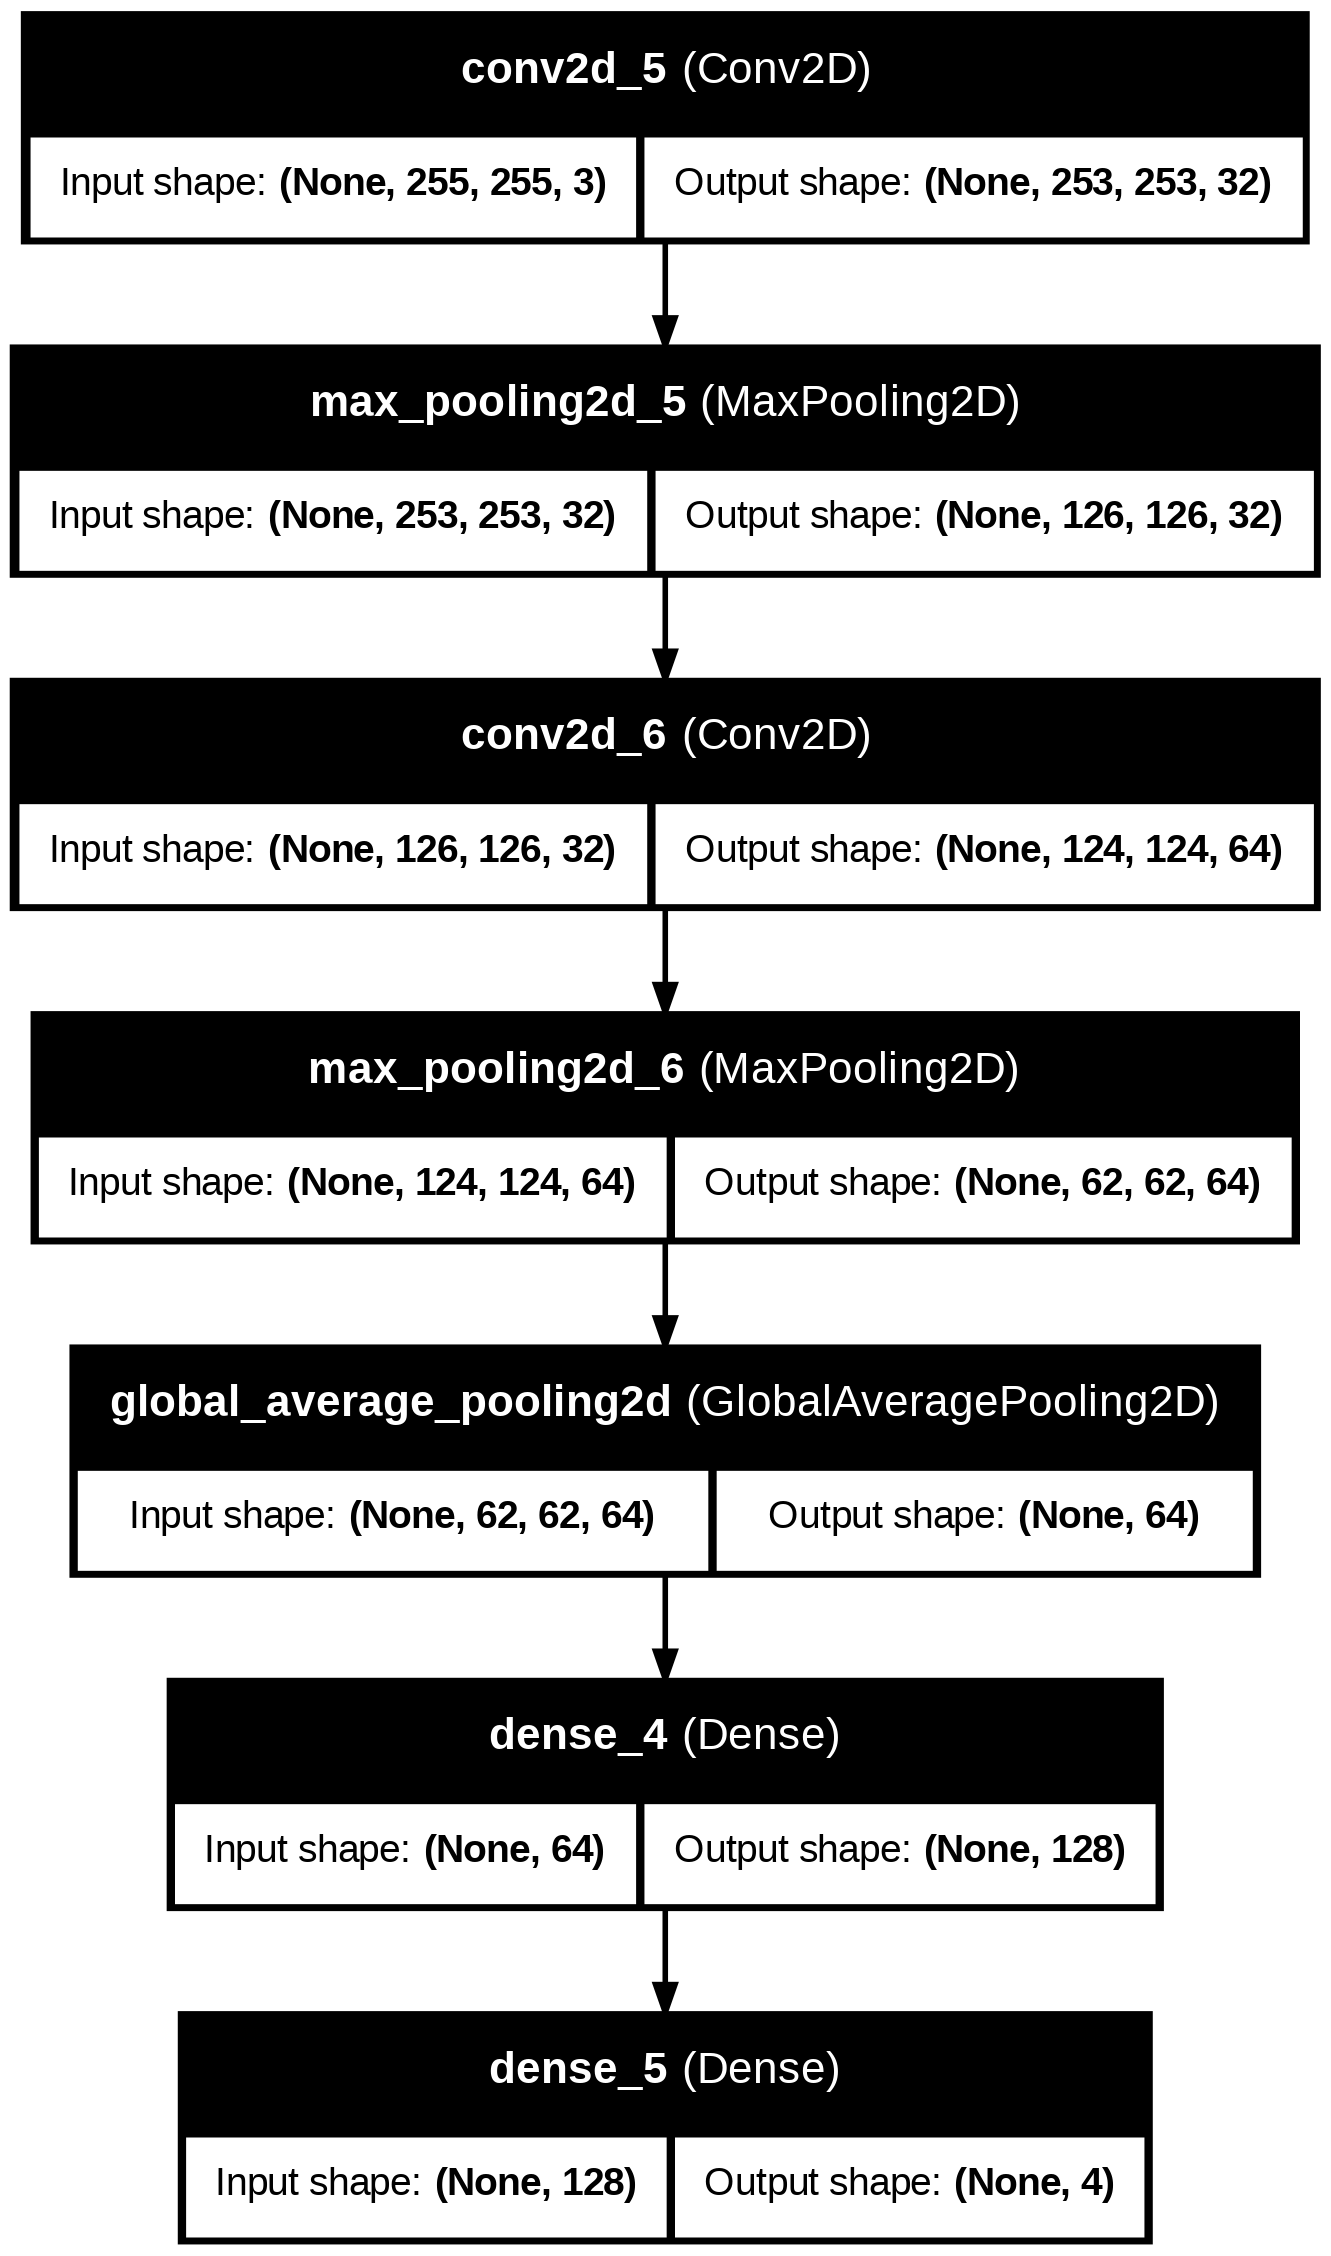

In [ ]:
from tensorflow.keras.utils import plot_model
from PIL import Image

plot_model(model, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)
display(Image.open('cnn_model.png'))

In [ ]:
import requests
import tempfile
from tensorflow.keras.preprocessing import image

urls = [
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/92000/92263/goldstone_oli_2018124_lrg.jpg',
    'https://img.freepik.com/free-photo/amazing-beautiful-sky-with-clouds_58702-1657.jpg'
]

for url in urls:
    response = requests.get(url)
    with tempfile.NamedTemporaryFile(delete=False) as f:
        f.write(response.content)
        img = image.load_img(f.name, target_size=(255,255))
        img = image.img_to_array(img) / 255.0
        img = np.expand_dims(img, axis=0)

        pred = model.predict(img)
        print(url, "→", class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
https://eoimages.gsfc.nasa.gov/images/imagerecords/92000/92263/goldstone_oli_2018124_lrg.jpg → desert
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
https://img.freepik.com/free-photo/amazing-beautiful-sky-with-clouds_58702-1657.jpg → cloudy


In [ ]:
train_generator.class_indices


{'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}

In [ ]:
class_names = ['cloud', 'desert', 'green_area', 'water']


In [ ]:
model.save("satellite_model.h5")


In [ ]:
import json

class_names = list(train_generator.class_indices.keys())

with open("class_names.json", "w") as f:
    json.dump(class_names, f)


In [ ]:
from google.colab import files
files.download("satellite_model.h5")
files.download("class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install gradio tensorflow pillow


In [ ]:
import tensorflow as tf
import numpy as np
import json
from PIL import Image
import gradio as gr


In [ ]:
# Load trained model
model = tf.keras.models.load_model("satellite_model.h5")

# Load class names EXACTLY as training
with open("class_names.json", "r") as f:
    class_names = json.load(f)

class_names


['cloudy', 'desert', 'green_area', 'water']

In [ ]:
def preprocess_image(img):
    img = img.resize((224, 224))   # SAME SIZE USED IN TRAINING
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [ ]:
def predict_satellite_image(image):
    image = Image.fromarray(image).convert("RGB")
    processed = preprocess_image(image)

    preds = model.predict(processed)[0]
    class_index = np.argmax(preds)

    prediction = class_names[class_index]
    confidence = round(preds[class_index] * 100, 2)

    return f"Prediction: {prediction}\nConfidence: {confidence}%"


In [ ]:
interface = gr.Interface(
    fn=predict_satellite_image,
    inputs=gr.Image(type="numpy", label="Upload Satellite Image"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🌍 Satellite Image Classification",
    description="""
    Upload a satellite image and the model will classify it into:
    Cloud, Desert, Green Area, or Water.
    """,
    theme="soft"
)


In [ ]:
interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://82368a354c2cf8a32b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install opencv-python


In [ ]:
import cv2
import tempfile
import collections


In [ ]:
def extract_frames(video_path, frame_rate=1):
    cap = cv2.VideoCapture(video_path)
    frames = []

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    interval = fps * frame_rate

    count = 0
    success = True

    while success:
        success, frame = cap.read()
        if not success:
            break

        if count % interval == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame))

        count += 1

    cap.release()
    return frames


In [ ]:
def predict_satellite_video(video):
    video_path = video

    frames = extract_frames(video_path)

    if len(frames) == 0:
        return "No frames extracted", "0%"

    predictions = []
    confidences = []

    for frame in frames:
        processed = preprocess_image(frame)
        preds = model.predict(processed)[0]

        class_index = np.argmax(preds)
        predictions.append(class_names[class_index])
        confidences.append(preds[class_index])

    final_class = collections.Counter(predictions).most_common(1)[0][0]
    final_confidence = round(np.mean(confidences) * 100, 2)

    return f"Prediction: {final_class}", f"Confidence: {final_confidence}%"


In [ ]:
video_interface = gr.Interface(
    fn=predict_satellite_video,
    inputs=gr.Video(label="Upload Satellite Video"),
    outputs=[
        gr.Textbox(label="Predicted Class"),
        gr.Textbox(label="Confidence")
    ],
    title="🎥 Satellite Video Classification",
    description="""
    Upload a satellite video (Cloud / Desert / Green Area / Water).
    The system extracts frames and predicts the correct class.
    """,
    theme="soft"
)


In [ ]:
!pip install opencv-python


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image
from collections import Counter


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/video')


['Water', 'green_land', 'cloudy', 'Desert']

In [ ]:
# ================= INSTALL DEPENDENCIES =================
!pip install opencv-python tensorflow

# ================= IMPORT LIBRARIES =================
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from PIL import Image
from google.colab import drive, files

# ================= MOUNT GOOGLE DRIVE =================
drive.mount('/content/drive')

# ================= SETTINGS =================
IMG_SIZE = 128   # Smaller = Faster training
CLASSES = ['Water', 'green_land', 'cloudy', 'Desert']
DATASET_PATH = '/content/drive/MyDrive/video'

# ================= FRAME EXTRACTION FUNCTION =================
def extract_frames_from_videos():
    images = []
    labels = []

    for label_index, class_name in enumerate(CLASSES):
        class_folder = os.path.join(DATASET_PATH, class_name)

        for video_file in os.listdir(class_folder):
            video_path = os.path.join(class_folder, video_file)

            cap = cv2.VideoCapture(video_path)
            fps = int(cap.get(cv2.CAP_PROP_FPS))
            frame_interval = max(1, fps // 2)  # Extract ~2 frames/sec

            count = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if count % frame_interval == 0:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

                    images.append(frame)
                    labels.append(label_index)

                count += 1

            cap.release()

    return np.array(images), np.array(labels)

# ================= EXTRACT FRAMES =================
print("🎥 Extracting frames from videos...")
X, y = extract_frames_from_videos()

print("✅ Frames extracted:", X.shape)

# ================= NORMALIZE =================
X = X / 255.0
y = to_categorical(y, num_classes=len(CLASSES))

# ================= TRAIN / TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================= BUILD CNN MODEL =================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================= TRAIN MODEL =================
print("🚀 Training model...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

# ================= SAVE MODEL =================
model.save('/content/drive/MyDrive/video_classifier.h5')
print("✅ Model Saved to Drive")

# ================= VIDEO PREDICTION FUNCTION =================
from collections import Counter

def predict_video(video_path):
    cap = cv2.VideoCapture(video_path)

    predictions = []
    confidences = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = np.expand_dims(frame / 255.0, axis=0)

        preds = model.predict(frame, verbose=0)[0]
        class_index = np.argmax(preds)

        predictions.append(CLASSES[class_index])
        confidences.append(preds[class_index])

    cap.release()

    final_prediction = Counter(predictions).most_common(1)[0][0]
    avg_confidence = round(np.mean(confidences) * 100, 2)

    return final_prediction, f"{avg_confidence}%"

# ================= UPLOAD & TEST VIDEO =================
print("📤 Upload a video to test")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

label, confidence = predict_video(video_path)

print("\n🎯 FINAL VIDEO PREDICTION:", label)
print("📊 CONFIDENCE:", confidence)



In [ ]:
video_interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97f80937685c1a8939.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
